## GRU

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [4]:
X_train_pad = np.load("../data/tokenization/X_train_pad.npy")
X_val_pad = np.load("../data/tokenization/X_val_pad.npy")
X_test_pad = np.load("../data/tokenization/X_test_pad.npy")

y_train = np.load("../data/tokenization/y_train.npy")
y_val = np.load("../data/tokenization/y_val.npy")
y_test = np.load("../data/tokenization/y_test.npy")

In [5]:
print("X_train_pad shape:", X_train_pad.shape)
print("X_val_pad shape:", X_val_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train_pad shape: (34998, 200)
X_val_pad shape: (7502, 200)
X_test_pad shape: (7500, 200)
y_train shape: (34998,)
y_val shape: (7502,)
y_test shape: (7500,)


In [6]:
VOCAB_SIZE = 10000
MAX_LEN = 200
EMBEDDING_DIM = 128
GRU_UNITS =64
LEARNING_RATE = 0.001
BATCH_SIZE = 32
EPOCHS = 10

In [ ]:
gru_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN,mask_zero=True),
    GRU(GRU_UNITS, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

c:\Users\berke\Desktop\IMDB_Sentimental_Analysis\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [8]:
gru_model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [12]:
gru_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,319,361 (5.03 MB)

 Trainable params: 1,319,361 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [10]:
history = gru_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping]
)

Epoch 1/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 89s 78ms/step - accuracy: 0.5059 - loss: 0.6925 - val_accuracy: 0.5079 - val_loss: 0.6908
Epoch 2/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 84s 76ms/step - accuracy: 0.5367 - loss: 0.6700 - val_accuracy: 0.5285 - val_loss: 0.6873
Epoch 3/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 85s 77ms/step - accuracy: 0.7404 - loss: 0.4691 - val_accuracy: 0.8671 - val_loss: 0.3190
Epoch 4/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 85s 77ms/step - accuracy: 0.9148 - loss: 0.2278 - val_accuracy: 0.8760 - val_loss: 0.3025
Epoch 5/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 91s 83ms/step - accuracy: 0.9456 - loss: 0.1545 - val_accuracy: 0.8659 - val_loss: 0.3591
Epoch 6/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 95s 87ms/step - accuracy: 0.9652 - loss: 0.1051 - val_accuracy: 0.8670 - val_loss: 0.4222


In [13]:
history_df = pd.DataFrame(history.history)
history_df

,accuracy,loss,val_accuracy,val_loss
0,0.505886,0.692470,0.507865,0.690799
1,0.536745,0.670008,0.528526,0.687347
2,0.740357,0.469144,0.867102,0.318959
3,0.914824,0.227752,0.876033,0.302520
4,0.945568,0.154454,0.865902,0.359057
5,0.965227,0.105118,0.866969,0.422190


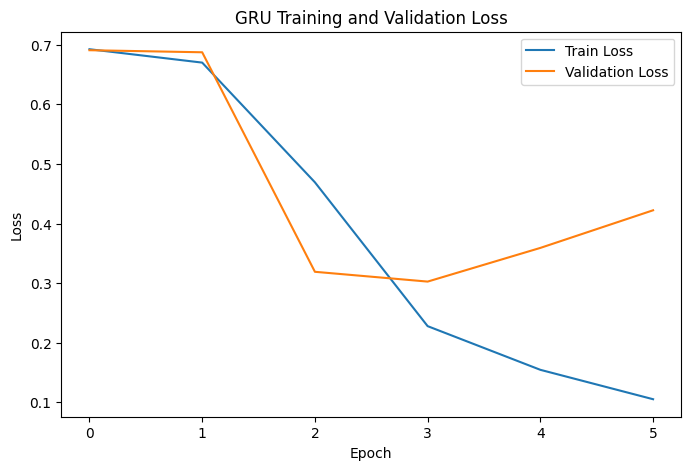

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU Training and Validation Loss")
plt.legend()
plt.show()

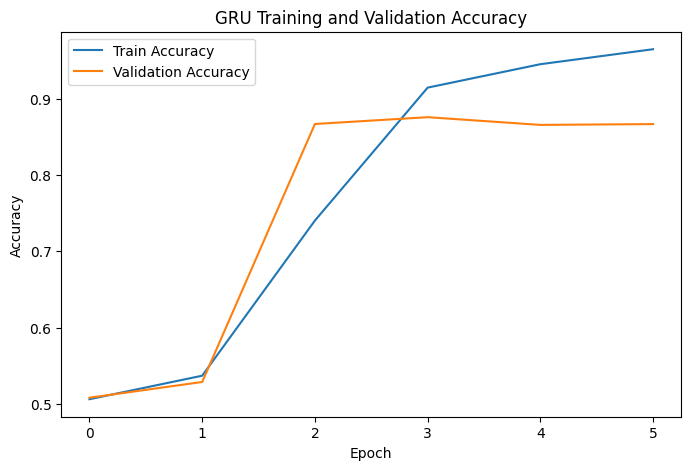

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GRU Training and Validation Accuracy")
plt.legend()
plt.show()

In [16]:
val_loss, val_accuracy = gru_model.evaluate(X_val_pad, y_val, verbose=0)

print("Validation Loss:", round(val_loss, 4))
print("Validation Accuracy:", round(val_accuracy, 4))

Validation Loss: 0.3025
Validation Accuracy: 0.876


In [17]:
y_val_prob = gru_model.predict(X_val_pad)
y_val_pred = (y_val_prob > 0.5).astype(int).flatten()

235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step


In [18]:
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)

print("Validation Metrics")
print(f"Accuracy : {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall   : {val_recall:.4f}")
print(f"F1 Score : {val_f1:.4f}")

Validation Metrics
Accuracy : 0.8760
Precision: 0.8787
Recall   : 0.8726
F1 Score : 0.8756


In [19]:
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.87      0.88      0.88      3751
           1       0.88      0.87      0.88      3751

    accuracy                           0.88      7502
   macro avg       0.88      0.88      0.88      7502
weighted avg       0.88      0.88      0.88      7502



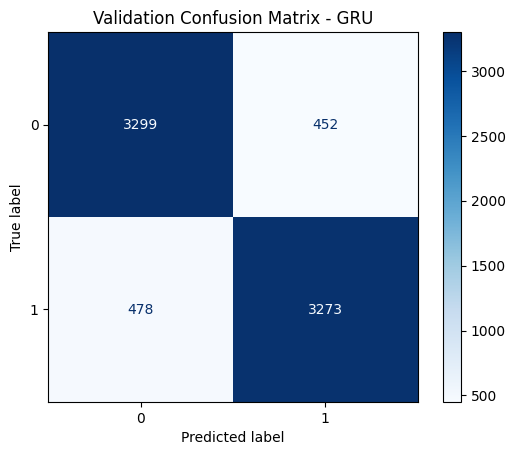

In [20]:
val_cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=val_cm)
disp.plot(cmap="Blues")
plt.title("Validation Confusion Matrix - GRU")
plt.show()

In [21]:
test_loss, test_accuracy = gru_model.evaluate(X_test_pad, y_test, verbose=0)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

Test Loss: 0.2846
Test Accuracy: 0.8873


In [22]:
y_test_prob = gru_model.predict(X_test_pad)
y_test_pred = (y_test_prob > 0.5).astype(int).flatten()

235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step


In [23]:
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("Test Metrics")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")

Test Metrics
Accuracy : 0.8873
Precision: 0.8916
Recall   : 0.8819
F1 Score : 0.8867


In [24]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.88      0.89      0.89      3750
           1       0.89      0.88      0.89      3750

    accuracy                           0.89      7500
   macro avg       0.89      0.89      0.89      7500
weighted avg       0.89      0.89      0.89      7500



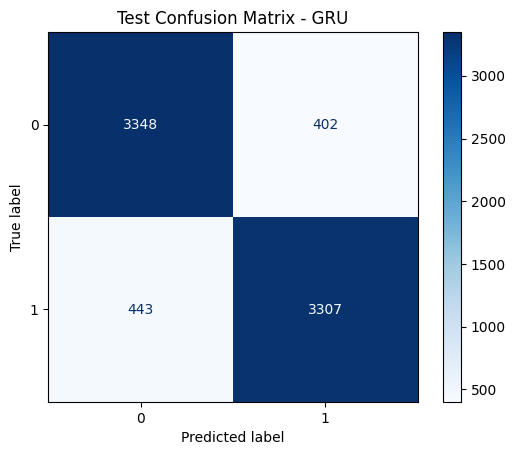

In [25]:
test_cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=test_cm)
disp.plot(cmap="Blues")
plt.title("Test Confusion Matrix - GRU")
plt.show()

In [26]:
gru_results = pd.DataFrame([
    {
        "Model": "GRU",
        "Validation Accuracy": val_accuracy,
        "Validation Precision": val_precision,
        "Validation Recall": val_recall,
        "Validation F1": val_f1,
        "Test Accuracy": test_accuracy,
        "Test Precision": test_precision,
        "Test Recall": test_recall,
        "Test F1": test_f1
    }
])

gru_results

,Model,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,GRU,0.876033,0.878658,0.872567,0.875602,0.887333,0.891615,0.881867,0.886714


In [27]:
gru_results.to_csv("../results/gru_results.csv", index=False)
print("GRU results saved.")

GRU results saved.


In [28]:
gru_model.save("../results/gru_model.keras")
print("GRU model saved.")

GRU model saved.
